In [1]:
from typing import TypedDict,Literal
from langgraph.graph import StateGraph, START, END

class LeaveManagerState(TypedDict):
    messages: [str]
    intent: str
    parsed_leave: [str]
    pending_write: [str]
    approve: bool


In [2]:


import os
from dotenv import load_dotenv
from leave_sheet import get_tools
from langchain.agents import create_agent

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY") or os.getenv("GOOGLE_API_KEY_1")

from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")

agent = create_agent(
    model=llm,           
    tools=get_tools(),
)


In [3]:
def _final_text(res):
    """Pull final assistant text from agent result, handling str or list content."""
    last = res['messages'][-1].content
    return last[0]['text'] if isinstance(last, list) else last

def router(state: LeaveManagerState):
    intent = state.get('intent', '')
    if intent:
        return {"intent": intent}
    prompt = f'''
    you are an helpful assistant
    check what is the actual query of the user. it can be either question or user is taking a leave and user send a mail for it.

    if it is a question then return "question"
    if it is a mail for leave the return "leave-email"

    {state['messages']}
'''
    res = agent.invoke({"messages":[prompt]})
    return {"intent": _final_text(res).strip()}

def chat1(state: LeaveManagerState):
    prompt = f'''
    you are an helpful hr assistant, you have the access of leave management sheet using tools, please use those tools and help user to get his question answers.
    {state['messages']}
'''
    print('invoking chat1')
    res = agent.invoke({"messages":[prompt]})
    return {"messages": [_final_text(res)]}

def chat2(state: LeaveManagerState):
    prompt = f'''
    you are an helpful hr assistant, you have the access of leave management sheet using tools, please use those tools and help user to get his question answers.
    {state['messages']}
'''
    res = agent.invoke({"messages":[prompt]})
    return {"messages": [_final_text(res)]}

In [4]:
def route_ticket(state: LeaveManagerState) -> Literal["question", "leave-email"]:
    return "leave-email" if "leave-email" in state["intent"].lower() else "question"

builder = StateGraph(LeaveManagerState)

builder.add_node("router", router)
builder.add_node("chat1", chat1)
builder.add_node("chat2", chat2)



builder.add_edge(START, "router")
builder.add_conditional_edges('router', route_ticket, {
    'question': "chat1",
    'leave-email': "chat2"
})

builder.add_edge("chat1", END)
builder.add_edge("chat2", END)


app = builder.compile()


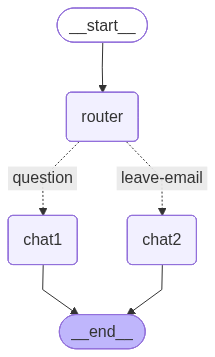

In [5]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not render image, here is the mermaid source instead:\n")
    print(app.get_graph().draw_mermaid())

In [8]:
result = app.invoke({'messages': ["My name is nikhilesh Ramoliya how many leaves i have?"]})
print(result['messages'])


invoking chat1
['Nikhilesh Ramoliya, you currently have 4 days of leave remaining.']
